<a href="https://colab.research.google.com/github/SaiSuhasBilla/Fashion-MNIST-CNN/blob/main/MNIST_fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification of Fashion Article Images using Convolutional Neural **Networks**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d zalando-research/fashionmnist
!unzip fashionmnist.zip -d fashionmnist

print("Setup complete! Data is ready for the CNN models.")

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
100% 68.8M/68.8M [00:00<00:00, 200MB/s]

Archive:  fashionmnist.zip
  inflating: fashionmnist/fashion-mnist_test.csv  
  inflating: fashionmnist/fashion-mnist_train.csv  
  inflating: fashionmnist/t10k-images-idx3-ubyte  
  inflating: fashionmnist/t10k-labels-idx1-ubyte  
  inflating: fashionmnist/train-images-idx3-ubyte  
  inflating: fashionmnist/train-labels-idx1-ubyte  
Setup complete! Data is ready for the CNN models.


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.svm import SVC
import os

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

train_path = 'fashionmnist/fashion-mnist_train.csv'
test_path = 'fashionmnist/fashion-mnist_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train_cnn = train_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1) / 255.0
X_test_cnn = test_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1) / 255.0
y_train_cat = tf.keras.utils.to_categorical(train_df['label'], 10)
y_test_cat = tf.keras.utils.to_categorical(test_df['label'], 10)

X_train_flat = train_df.drop('label', axis=1).values / 255.0
X_test_flat = test_df.drop('label', axis=1).values / 255.0
y_train = train_df['label'].values
y_test = test_df['label'].values

def add_paper_backend(x):
    """Adds the MLP backend: 128-neuron Dense, 50% Dropout, and Softmax[cite: 105, 113]."""
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    return layers.Dense(10, activation='softmax')(x)

def build_vanilla_cnn():
    inputs = Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    outputs = add_paper_backend(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bn_cnn():
    """CNN with Batch Normalization to accelerate learning[cite: 12, 90]."""
    inputs = Input(shape=(28, 28, 1))
    x = layers.BatchNormalization()(inputs)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    outputs = add_paper_backend(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_skip_cnn():
    """SOTA model with Residual Skip Connections[cite: 12, 97]."""
    inputs = Input(shape=(28, 28, 1))
    x1_in = layers.BatchNormalization()(inputs)
    x1_conv = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x1_in)
    shortcut1 = layers.Conv2D(32, (1, 1), padding='same')(x1_in)
    x1_add = layers.Add()([x1_conv, shortcut1])
    x1_pool = layers.MaxPooling2D((2, 2))(x1_add)
    x2_in = layers.BatchNormalization()(x1_pool)
    x2_conv = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x2_in)
    x2_add = layers.Add()([x2_conv, x2_in])
    x2_pool = layers.MaxPooling2D((2, 2))(x2_add)
    outputs = add_paper_backend(x2_pool)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

results = {"EDEN (Literature Reference)": 0.9060}

print("Training SVC Baseline...")
svc = SVC(C=10, kernel='rbf')
svc.fit(X_train_flat[:10000], y_train[:10000])
results["SVC Baseline"] = svc.score(X_test_flat, y_test)

variants = {
    "Proposed CNN2 (Vanilla)": build_vanilla_cnn(),
    "Proposed CNN2 + BatchNorm": build_bn_cnn(),
    "Proposed CNN2 + BatchNorm + Skip": build_skip_cnn()
}

for name, model in variants.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_cnn, y_train_cat, epochs=10, batch_size=128, verbose=1)
    _, acc = model.evaluate(X_test_cnn, y_test_cat, verbose=0)
    results[name] = acc

print("\n" + "="*50)
print(f"{'Model Architecture':<35} | {'Test Accuracy':<10}")
print("-" * 50)
for name, accuracy in results.items():
    print(f"{name:<35} | {accuracy*100:>12.2f}%")

Mounted at /content/drive
Training SVC Baseline...

Training Proposed CNN2 (Vanilla)...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 106ms/step - accuracy: 0.7756 - loss: 0.6212
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - accuracy: 0.8532 - loss: 0.4103
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.8717 - loss: 0.3552
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.8824 - loss: 0.3238
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.8926 - loss: 0.2991
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 103ms/step - accuracy: 0.8988 - loss: 0.2797
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - accuracy: 0.9043 - loss: 0.2664
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.9083 - loss: 0.2527
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 102ms/step - accuracy: 0.9119 - loss: 0.2409
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.9164 - loss: 0.2286

Training Proposed CN

Please upload a fashion article image.


Saving shoe.png to shoe.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


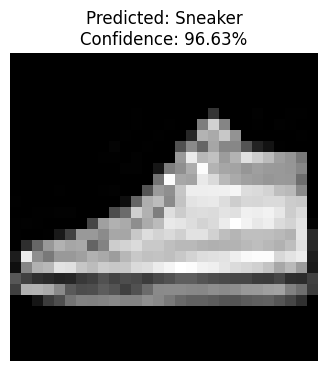

The model identifies this image as a Sneaker.


In [3]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


labels = {0: "T-Shirt/Top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}

print("Please upload a fashion article image.")
uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(28, 28), color_mode="grayscale")
    img_array = image.img_to_array(img)

    img_array = img_array / 255.0



    img_batch = np.expand_dims(img_array, axis=0)

    best_model = variants["Proposed CNN2 + BatchNorm + Skip"]
    predictions = best_model.predict(img_batch)
    result_idx = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {labels[result_idx]}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"The model identifies this image as a {labels[result_idx]}.")

In [4]:
# Save the final best-performing model after all processing is complete
save_dir = '/content/drive/MyDrive/Fashion_Project'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save the SOTA (Skip Connection) model
final_model_path = os.path.join(save_dir, 'fashion_model_final_v2.h5')
variants["Proposed CNN2 + BatchNorm + Skip"].save(final_model_path)

print(f"\nFinal processing complete.")
print(f"The best model has been saved to your Google Drive: {final_model_path}")


Final processing complete.
The best model has been saved to your Google Drive: /content/drive/MyDrive/Fashion_Project/fashion_model_final_v2.h5
